In [177]:
import pandas as pd
pumpkins = pd.read_csv('../data/US-pumpkins.csv')
# Display the first 5 rows of the DataFrame
pumpkins.head()
print(f"\nTotal rows after filtering: {len(pumpkins)}")


Total rows after filtering: 1757


In [178]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
pumpkins.head()
print(f"\nTotal rows after filtering: {len(pumpkins)}")


Total rows after filtering: 415


In [179]:
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [180]:
columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
# the loc function which extracts from the original dataframe a group of rows (passed as first parameter) and columns (passed as second parameter). The expression : in the case below means "all rows".
pumpkins = pumpkins.loc[:, columns_to_select]

In [181]:
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
print(month)

Index([ 9,  9, 10, 10, 10, 10, 10, 10, 10, 10,
       ...
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9],
      dtype='int32', name='Date', length=415)


In [182]:
new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Price': price})

In [183]:
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

# Display results
print(new_pumpkins.head())

    Month               Package  Low Price  High Price  Price
70      9  1 1/9 bushel cartons       15.0        15.0   13.5
71      9  1 1/9 bushel cartons       18.0        18.0   16.2
72     10  1 1/9 bushel cartons       18.0        18.0   16.2
73     10  1 1/9 bushel cartons       17.0        17.0   15.3
74     10  1 1/9 bushel cartons       15.0        15.0   13.5


In [184]:
import matplotlib.pyplot as plt

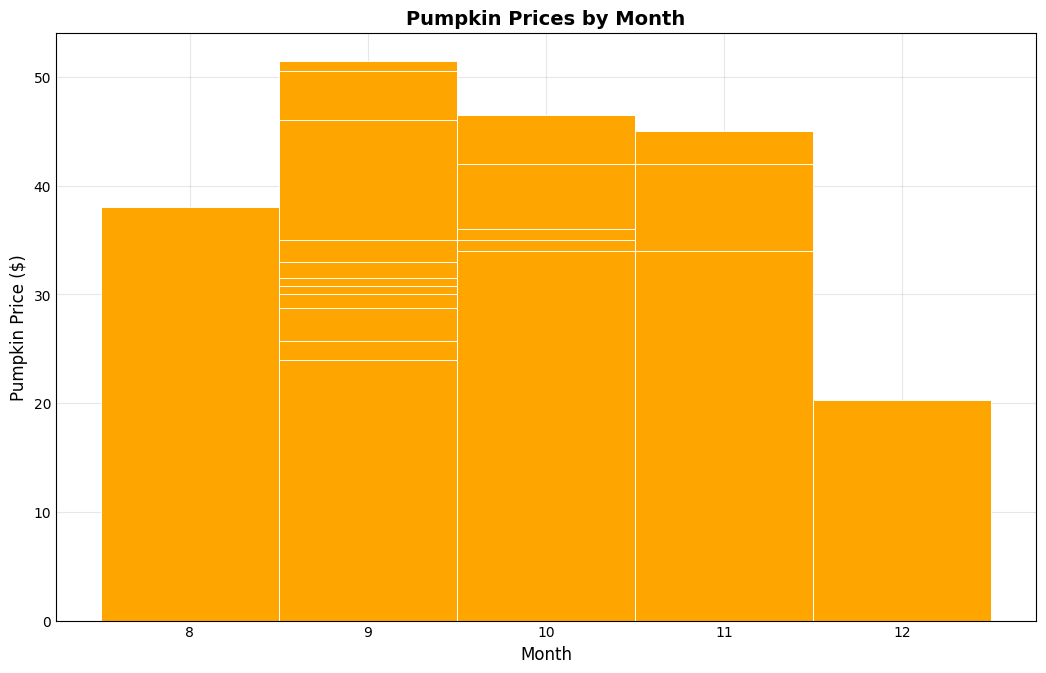

In [185]:
price = new_pumpkins.Price
month = new_pumpkins.Month

plt.style.use('_mpl-gallery')

# Extract data manually
price = new_pumpkins['Price']
month = new_pumpkins['Month']

# Create figure and axes objects
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with detailed customization
ax.bar(month, price, width=1, edgecolor="white", linewidth=0.7, color='orange')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Pumpkin Price ($)', fontsize=12)
ax.set_title('Pumpkin Prices by Month', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.show()

What Gets Auto-Labeled
X-axis (automatically labeled):

Uses the index name from the grouped result
groupby(['Month']) creates an index with name 'Month'
Pandas automatically sets x-axis label to "Month"
Y-axis (NOT automatically labeled):

Pandas doesn't know what to call the y-axis by default
The aggregated values (.mean() results) don't have a descriptive name
You need to manually add plt.ylabel() or use a more explicit approach

<Axes: xlabel='Month'>

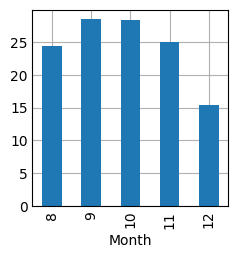

In [186]:
# Pandas plotting - simple and concise
# Automatically handles DataFrame structure
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')

Text(0, 0.5, 'Pumpkin Price')

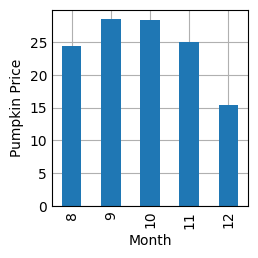

In [188]:
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")

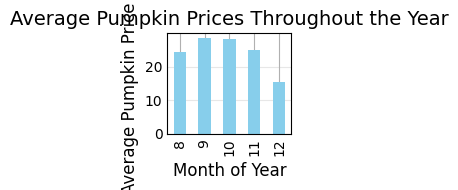

In [189]:
# Start with Pandas for convenience
ax = new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar', color='skyblue')

# Then customize with Matplotlib
ax.set_xlabel('Month of Year', fontsize=12)
ax.set_ylabel('Average Pumpkin Price ($)', fontsize=12)
ax.set_title('Average Pumpkin Prices Throughout the Year', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()